In [1]:
#import libraries 
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")
sentAnalyser = SentimentIntensityAnalyzer()
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\binh\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
#set the folder path 
processed_folder = Path("../data/processed")
output_folder = Path("../outputs")
figures_folder = output_folder / "figures"
tables_folder = output_folder / "tables"

#load the processed Q3 and Q4 datasets 
q3 = pd.read_csv(processed_folder / "Q3_final_processed.csv")
q4 = pd.read_csv(processed_folder / "Q4_final_processed.csv")

#show the number of comments in each dataset
print("Q3 comments:", len(q3))
print("Q4 comments:", len(q4))

Q3 comments: 2768
Q4 comments: 4475


In [4]:
#define token collection function 
def get_tokens(series):
    #create an empty list to store the words
    all_tokens = []
    #loop through each row in each column 
    for text in series.fillna(""):
        #split the text into individual words and add them to the list
        all_tokens.extend(str(text).split())
    return all_tokens
#get all tokens from Q3 comments
q3_tokens = get_tokens(q3["tokens_joined"])
#get all tokens from Q4 comments
q4_tokens = get_tokens(q4["tokens_joined"])

#show the total number of tokens in each dataset
print("Q3 total tokens:", len(q3_tokens))
print("Q4 total tokens:", len(q4_tokens))

Q3 total tokens: 19454
Q4 total tokens: 37610


In [6]:
#define word frequency function 
def word_frequency(tokens, top_n=30):
    #counts how many time each word appears 
    counter = Counter(tokens)
    #convert the most common words into a dataframe
    return pd.DataFrame(counter.most_common(top_n), columns=["word", "frequency"])

#get the top 30 most frequent words for Q3
q3_word_freq = word_frequency(q3_tokens, 30)

#get the top 30 most frequent words for Q4
q4_word_freq = word_frequency(q4_tokens, 30)

#save as a CSV 
q3_word_freq.to_csv(tables_folder / "q3_word_frequency.csv", index=False)
q4_word_freq.to_csv(tables_folder / "q4_word_frequency.csv", index=False)

#show the Q3 word frequency table
print("Q3 most common words:")
display(q3_word_freq)
#show the Q4 word frequency table
print("Q4 most common words:")
display(q4_word_freq)

Q3 most common words:


,word,frequency
0,real,168
1,artist,162
2,human,141
3,artists,113
4,work,84
5,draw,72
6,love,69
7,digital,65
8,humans,56
9,life,56


Q4 most common words:


,word,frequency
0,artist,369
1,draw,237
2,work,233
3,artists,195
4,image,185
5,love,165
6,human,147
7,real,143
8,drawing,143
9,create,135


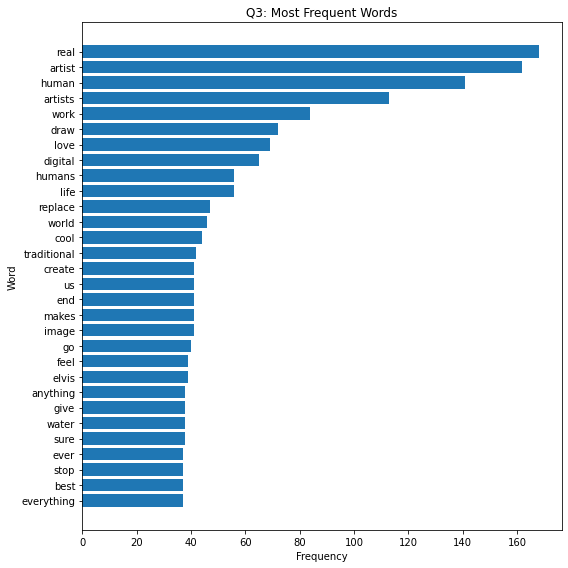

In [7]:
#create a bar chart to represent the top 30 most frequent words for Q3

plt.figure(figsize=(8, 8))

plt.barh(q3_word_freq["word"][::-1], q3_word_freq["frequency"][::-1])

plt.title("Q3: Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.savefig(figures_folder / "q3_word_frequency_horizontal.png", dpi=300)
plt.show()

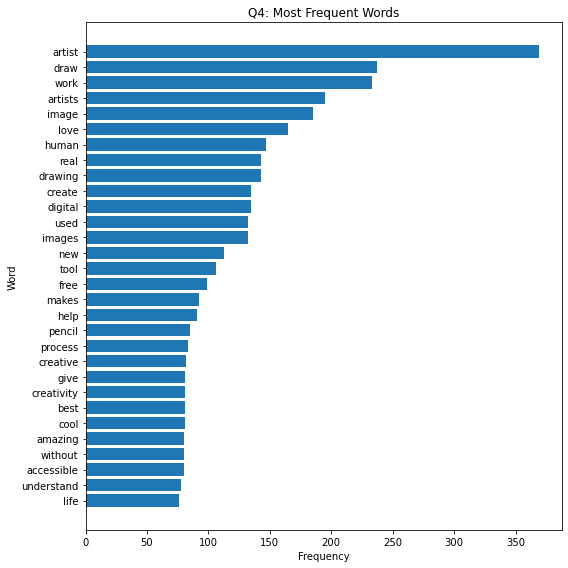

In [8]:
#create a bar chart to represent the top 30 most frequent words for Q4
plt.figure(figsize=(8, 8))

plt.barh(q4_word_freq["word"][::-1], q4_word_freq["frequency"][::-1])

plt.title("Q4: Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.savefig(figures_folder / "q4_word_frequency_horizontal.png", dpi=300)
plt.show()

In [10]:
#define bigram frequency function 
def bigram_frequency_from_comments(df, top_n=30):
    #create a counter to count bigram frequency 
    counter = Counter()
    
    #loop through each cleaned token string
    for text in df["tokens_joined"].fillna(""):
        #split the text into individual words
        tokens = str(text).split()

        #create bigrams only within the came comment
        bigrams = zip(tokens[:-1], tokens[1:])
         #add the bigrams to the counter
        counter.update(bigrams)
    
    #convert the most common bigrams into table rows
    rows = [
        (" ".join(pair), count)
        for pair, count in counter.most_common(top_n)
    ]

    return pd.DataFrame(rows, columns=["bigram", "frequency"])

#get the top 30 bigrams for Q3
q3_bigram_freq = bigram_frequency_from_comments(q3, 30)

#get the top 30 bigrams for Q4
q4_bigram_freq = bigram_frequency_from_comments(q4, 30)

#show the bigram frequency tables
display(q3_bigram_freq)
display(q4_bigram_freq)

,bigram,frequency
0,artificial intelligence,10
1,real artist,10
2,real artists,10
3,ask question,9
4,traditional artist,9
5,trying steal,8
6,replace artists,8
7,steal life,7
8,traditional digital,7
9,life cause,6


,bigram,frequency
0,super helpful,21
1,digital artist,17
2,bring back,17
3,traditional artist,17
4,real artist,14
5,artist draw,13
6,generated images,12
7,creative process,11
8,makes accessible,11
9,custom nodes,10


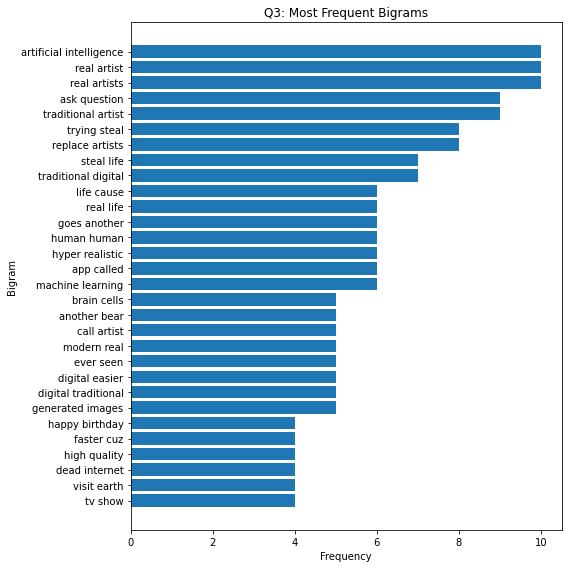

In [11]:
#create a bar chart to represent the bigram for Q3
plt.figure(figsize=(8, 8))
plt.barh(q3_bigram_freq["bigram"][::-1], q3_bigram_freq["frequency"][::-1])
plt.title("Q3: Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.tight_layout()
plt.savefig(figures_folder / "q3_bigram_frequency_horizontal.png", dpi=300)
plt.show()

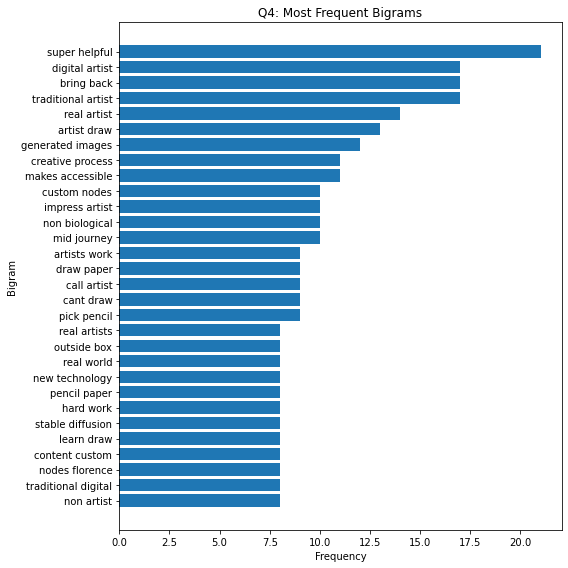

In [12]:
#create a bar chart to represent the bigram for Q4
plt.figure(figsize=(8, 8))
plt.barh(q4_bigram_freq["bigram"][::-1], q4_bigram_freq["frequency"][::-1])
plt.title("Q4: Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.tight_layout()
plt.savefig(figures_folder / "q4_bigram_frequency_horizontal.png", dpi=300)
plt.show()

In [14]:
#define classify sentiment function 
def classify_sentiment(compound):
    #positive sentiment if the compound score is 0.05 or higher
    if compound >= 0.05:
        return "Positive"
    #negative sentiment if the compound score is -0.05 or lower
    elif compound <= -0.05:
        return "Negative"
    #otherwise it's neutral 
    else:
        return "Neutral"

#define VADER sentiment function 
def vaderSentimentAnalysisYouTube(df, text_col="comment_text_clean"):
    
    #create a copy of the dataset 
    #so that the original dataset isn't changed 
    result = df.copy()
    
    #create empty lists to store VADER sentiment scores
    neg_scores = []
    neu_scores = []
    pos_scores = []
    compound_scores = []
    
    #loop through each comment
    for text in result[text_col].fillna(""):
        #convert comment to text format
        text = str(text)
        
        #calculate sentiment score
        dSentimentScores = sentAnalyser.polarity_scores(text)
        
        #store score in the relevant list 
        neg_scores.append(dSentimentScores["neg"])
        neu_scores.append(dSentimentScores["neu"])
        pos_scores.append(dSentimentScores["pos"])
        compound_scores.append(dSentimentScores["compound"])
    
    #add the VADER scores to the dataframe 
    result["neg"] = neg_scores
    result["neu"] = neu_scores
    result["pos"] = pos_scores
    result["compound"] = compound_scores
    result["sentiment"] = result["compound"].apply(classify_sentiment)

    return result

In [16]:
#run the VADER analysis for Q3
q3_sent = vaderSentimentAnalysisYouTube(q3, text_col="comment_text_clean")

#run the VADER analysis for Q4
q4_sent = vaderSentimentAnalysisYouTube(q4, text_col="comment_text_clean")

#save the sentiments as a CSV
q3_sent.to_csv(tables_folder / "q3_vader_sentiment_results.csv", index=False)
q4_sent.to_csv(tables_folder / "q4_vader_sentiment_results.csv", index=False)

In [17]:
#define the sentiment summary function 
def sentiment_summary(df):
    #count how many comments are in each sentiment category
    summary = df["sentiment"].value_counts().reset_index()
    #rename the columns
    summary.columns = ["sentiment", "comment_count"]
    #calculate percentage 
    summary["percentage"] = round(summary["comment_count"] / len(df) * 100, 2)
    return summary

#create sentiment summary tables for Q3
q3_sentiment_summary = sentiment_summary(q3_sent)
#create sentiment summary tables for Q4
q4_sentiment_summary = sentiment_summary(q4_sent)

#show the summary table 
display(q3_sentiment_summary)
display(q4_sentiment_summary)

#save the summary tables as CSV
q3_sentiment_summary.to_csv(tables_folder / "q3_sentiment_summary.csv", index=False)
q4_sentiment_summary.to_csv(tables_folder / "q4_sentiment_summary.csv", index=False)

,sentiment,comment_count,percentage
0,Neutral,1099,39.70
1,Positive,1040,37.57
2,Negative,629,22.72


,sentiment,comment_count,percentage
0,Positive,2157,48.20
1,Neutral,1425,31.84
2,Negative,893,19.96


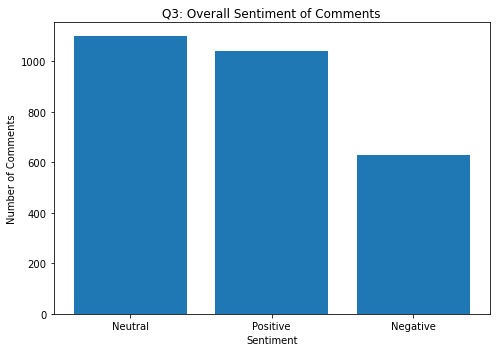

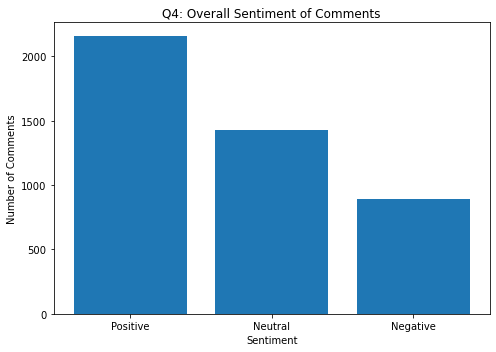

In [18]:
#create a bar chart to represent the sentiment for Q3
plt.figure(figsize=(7, 5))
plt.bar(q3_sentiment_summary["sentiment"], q3_sentiment_summary["comment_count"])
plt.title("Q3: Overall Sentiment of Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.savefig(figures_folder / "q3_overall_sentiment.png", dpi=300)
plt.show()

#create a bar chart to represent the sentiment for Q4
plt.figure(figsize=(7, 5))
plt.bar(q4_sentiment_summary["sentiment"], q4_sentiment_summary["comment_count"])
plt.title("Q4: Overall Sentiment of Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.savefig(figures_folder / "q4_overall_sentiment.png", dpi=300)
plt.show()

In [19]:
#convert cleaned token text into a list of comments for Q3
q3_posts = q3_sent["tokens_joined"].fillna("").astype(str).tolist()
#convert cleaned token text into a list of comments for Q4
q4_posts = q4_sent["tokens_joined"].fillna("").astype(str).tolist()

In [20]:
#set the number of topics for LDA topic modelling
topicNum = 5
#set how many top words to show for each topic
wordNumToDisplay = 12
#set the maximum number of words/features used in the model
featureNum = 1500

In [21]:
#define the LDA topic modelling function 
def run_lda(posts, topicNum=5, wordNumToDisplay=12, featureNum=1500):
    #convert comments into a word-count matrix
    tfVectorizer = CountVectorizer(
        max_df=0.95,
        min_df=5,
        max_features=featureNum
    )

    tf = tfVectorizer.fit_transform(posts)

    #get the list of words from the vectorizer
    try:
        tfFeatureNames = tfVectorizer.get_feature_names_out()
    except AttributeError:
        tfFeatureNames = tfVectorizer.get_feature_names()

    #create and run the LDA model 
    ldaModel = LatentDirichletAllocation(
        n_components=topicNum,
        max_iter=10,
        learning_method="online",
        random_state=42
    )
    
    #train the LDA model
    ldaModel.fit(tf)

    #create an empty list to store topic results
    topics = []
    
    #loop through each topic found by the LDA model
    for topicId, topicDist in enumerate(ldaModel.components_):
        #get the index numbers of the top words
        topWordIds = topicDist.argsort()[:-wordNumToDisplay - 1:-1]
        #convert the word index numbers into actual words
        topWords = [tfFeatureNames[i] for i in topWordIds]
    
        #store the topic number and its top words
        topics.append({
            "topic_number": topicId + 1,
            "top_words": ", ".join(topWords)
        })
    
    #convert into dataframe
    topicTable = pd.DataFrame(topics)

    #get dominant topic for each comment
    topicDistribution = ldaModel.transform(tf)
    dominantTopics = topicDistribution.argmax(axis=1) + 1
    topicProbabilities = topicDistribution.max(axis=1)

    return ldaModel, tfVectorizer, tf, tfFeatureNames, topicTable, dominantTopics, topicProbabilities

In [22]:
#run topic modelling for Q3
q3_ldaModel, q3_tfVectorizer, q3_tf, q3_tfFeatureNames, q3_topicTable, q3_dominantTopics, q3_topicProbabilities = run_lda(
    q3_posts,
    topicNum=topicNum,
    wordNumToDisplay=wordNumToDisplay,
    featureNum=featureNum
)

#show the topic table 
print("Q3 LDA Topics")
display(q3_topicTable)

#save as a CSV
q3_topicTable.to_csv(tables_folder / "q3_lda_topics.csv", index=False)

Q3 LDA Topics


,topic_number,top_words
0,1,"real, world, create, feel, realistic, new, wat..."
1,2,"artist, digital, go, soul, traditional, used, ..."
2,3,"human, work, draw, love, humans, cool, real, e..."
3,4,"artists, guy, last, man, image, shit, cuz, rep..."
4,5,"elvis, anything, artists, name, music, show, m..."


In [23]:
#run topic modelling for Q4
q4_ldaModel, q4_tfVectorizer, q4_tf, q4_tfFeatureNames, q4_topicTable, q4_dominantTopics, q4_topicProbabilities = run_lda(
    q4_posts,
    topicNum=topicNum,
    wordNumToDisplay=wordNumToDisplay,
    featureNum=featureNum
)

#show the topic table 
print("Q4 LDA Topics")
display(q4_topicTable)

#save as a CSV
q4_topicTable.to_csv(tables_folder / "q4_lda_topics.csv", index=False)

Q4 LDA Topics


,topic_number,top_words
0,1,"work, love, artist, artists, real, new, human,..."
1,2,"used, digital, drawing, pencil, cool, artist, ..."
2,3,"trying, guy, end, find, future, human, maybe, ..."
3,4,"draw, artist, create, amazing, long, stuff, im..."
4,5,"free, image, understand, tools, part, model, w..."


In [24]:
#create a copy of the sentiment dataset for Q3
q3_topics_df = q3_sent.copy()
#add the dominant topic number for each Q3 comment
q3_topics_df["dominant_topic"] = q3_dominantTopics
#add the probability score for the dominant topic
q3_topics_df["topic_probability"] = q3_topicProbabilities

#create a copy of the sentiment dataset for Q4
q4_topics_df = q4_sent.copy()
#add the dominant topic number for each Q3 comment
q4_topics_df["dominant_topic"] = q4_dominantTopics
#add the probability score for the dominant topic
q4_topics_df["topic_probability"] = q4_topicProbabilities

#save results into a CSV file
q3_topics_df.to_csv(tables_folder / "q3_comments_with_topics.csv", index=False)
q4_topics_df.to_csv(tables_folder / "q4_comments_with_topics.csv", index=False)

In [25]:
#define topic size summary function 
def topic_size_summary(df):
    #count how many comments are assigned to each dominant topic
    summary = df["dominant_topic"].value_counts().reset_index()
    #rename the columns
    summary.columns = ["topic_number", "comment_count"]
    #sort the topics by topic number
    summary = summary.sort_values("topic_number")
    #calculate percentage 
    summary["percentage"] = round(summary["comment_count"] / len(df) * 100, 2)
    return summary

#create summary for Q3
q3_topic_size = topic_size_summary(q3_topics_df)
#create summary for Q4
q4_topic_size = topic_size_summary(q4_topics_df)

#display the summary for Q3
print("Q3 Topic Size")
display(q3_topic_size)

#display the summary for Q4
print("Q4 Topic Size")
display(q4_topic_size)

#save summary as a CSV
q3_topic_size.to_csv(tables_folder / "q3_topic_size_summary.csv", index=False)
q4_topic_size.to_csv(tables_folder / "q4_topic_size_summary.csv", index=False)

Q3 Topic Size


,topic_number,comment_count,percentage
0,1,800,28.90
2,2,555,20.05
1,3,664,23.99
4,4,370,13.37
3,5,379,13.69


Q4 Topic Size


,topic_number,comment_count,percentage
0,1,1318,29.45
1,2,877,19.60
3,3,724,16.18
2,4,865,19.33
4,5,691,15.44


In [26]:
#dsiplay full column to see all words
pd.set_option("display.max_colwidth", None)

print("Q3 Topics")
display(q3_topicTable)

print("Q4 Topics")
display(q4_topicTable)

Q3 Topics


,topic_number,top_words
0,1,"real, world, create, feel, realistic, new, water, everything, best, yes, stuff, ask"
1,2,"artist, digital, go, soul, traditional, used, stop, different, pretty, bad, help, part"
2,3,"human, work, draw, love, humans, cool, real, end, us, ever, tell, keep"
3,4,"artists, guy, last, man, image, shit, cuz, replace, gonna, paint, talking, nothing"
4,5,"elvis, anything, artists, name, music, show, mean, drawing, jobs, beautiful, eat, sound"


Q4 Topics


,topic_number,top_words
0,1,"work, love, artist, artists, real, new, human, help, tool, images, life, anything"
1,2,"used, digital, drawing, pencil, cool, artist, paper, midjourney, traditional, keep, app, man"
2,3,"trying, guy, end, find, future, human, maybe, another, almost, start, last, hands"
3,4,"draw, artist, create, amazing, long, stuff, images, work, stop, generated, beautiful, tell"
4,5,"free, image, understand, tools, part, model, workflow, without, easy, makes, animation, true"
